In [1]:
import torch
import numpy as np
from torch import nn
from torchvision import transforms, datasets

from matplotlib.pyplot import imshow, show

from torch.utils.data import DataLoader

from math import floor

In [2]:
def nd(shape, padding, kernel_size, stride):
    h = shape[0]
    w = shape[1]

    h = floor((h + 2 * padding - kernel_size) / stride) + 1
    w = floor((w + 2 * padding - kernel_size) / stride) + 1

    return (h,w)

In [44]:
nd((26,26), padding = 0, kernel_size= 2, stride= 2)

(13, 13)

In [3]:
tr_data = datasets.MNIST(root= "MNIST", train= True, transform = transforms.ToTensor(), download = True)
ts_data = datasets.MNIST(root= "MNIST", train= False, transform = transforms.ToTensor(), download = True)

In [4]:
tr_data = DataLoader(dataset= tr_data, batch_size= 32, drop_last= True, shuffle= True)
ts_data = DataLoader(dataset= ts_data, batch_size= 32, drop_last= True, shuffle= False)

In [35]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(in_channels= 1, out_channels= 16, kernel_size= 3, stride= 1, padding = 1), ## 28 x 28
            nn.ReLU(),
            nn.Conv2d(in_channels= 16, out_channels= 20, kernel_size= 3, padding= 0), ## 26 x 26
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2), ## 13 x 13
            nn.Conv2d(in_channels=20, out_channels= 22, stride=1, kernel_size= 3), ## 11 x 11
            nn.ReLU(),
            nn.Conv2d(in_channels=22, out_channels= 25, stride=1, kernel_size= 3), ## 9 x 9
            nn.ReLU(),
            nn.Conv2d(in_channels=25, out_channels= 28, stride=1, kernel_size= 3), ## 7 x 7
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(output_size=(1,1))
        )

        self.dense_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28,10)
        )

    def forward(self,x):
        x = self.conv_layer(x)
        x = self.dense_layer(x)
        return x
    
    def get_editted(self,x):
        x = self.forward(x)
        x = torch.argmax(torch.softmax(x, dim = 1), dim= 1)

        return x


In [36]:
model = ANN().to("cuda")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 3e-4)
epoch_number = 10

In [37]:
for epoch in range(epoch_number):
    i = 0
    n_r = 0
    for (X,y) in tr_data:
        X = X.to("cuda")
        y = y.to("cuda")
        model.train()
        logits = model(X)
        loss = loss_fn(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.inference_mode():
            i += 32
            n_r += torch.sum(model.get_editted(X) == y)


    print(f"Epoch : {epoch} Accuracy : {n_r / i}")



Epoch : 0 Accuracy : 0.5920500159263611
Epoch : 1 Accuracy : 0.8500999808311462
Epoch : 2 Accuracy : 0.9100666642189026
Epoch : 3 Accuracy : 0.9350666999816895
Epoch : 4 Accuracy : 0.9467499852180481


KeyboardInterrupt: 

In [22]:
for (X,y) in ts_data:
        model.eval()
        with torch.inference_mode():
            i += 32
            n_r += torch.sum(model.get_editted(X.to("cuda")) == y.to("cuda"))

In [11]:
n_r/i

tensor(0.9814, device='cuda:0')

In [74]:
tr_data.dataset.data[0].unsqueeze(0).shape

torch.Size([1, 28, 28])

tensor([1], device='cuda:0')


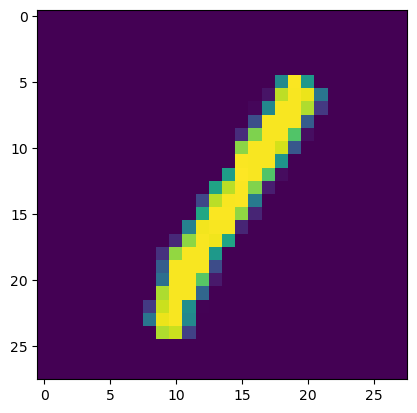

In [ ]:
a = 23

print(model.get_editted(tr_data.dataset.data[a].unsqueeze(0).unsqueeze(0).to("cuda") / 255))
imshow(tr_data.dataset.data[a])

RuntimeError: mat1 and mat2 shapes cannot be multiplied (22x49 and 1078x10)

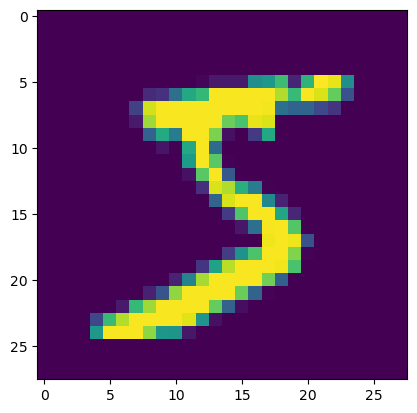

In [76]:
imshow(tr_data.dataset.data[0])
model.eval()
with torch.inference_mode():
    model(tr_data.dataset.data[0].unsqueeze(0).to("cuda") / 255)